# Task 1 — Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Tech Stack:** Python, scikit-learn, pandas, matplotlib/seaborn, Jupyter Notebook

## 1. Import Libraries & Load the Dataset
The Iris dataset is already built into scikit-learn, so no external download of dataset is needed.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Load the dataset directly from sklearn
iris = load_iris()

# Build a DataFrame with readable column names
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis (EDA)
Check the shape, data types, missing values, and descriptive statistics of the dataset.

In [3]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

Shape of dataset: (150, 5)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [4]:
# Descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Class balance check
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observation:** After running .describe(), I found that the dataset has 1 categorical target, 4 numeric features, 150 rows, 0 missing values, and it is well-balanced with 50 samples per species.

## 3. Visualizations
PairPlot to see feature distributions by species, and box plots for each individual feature.

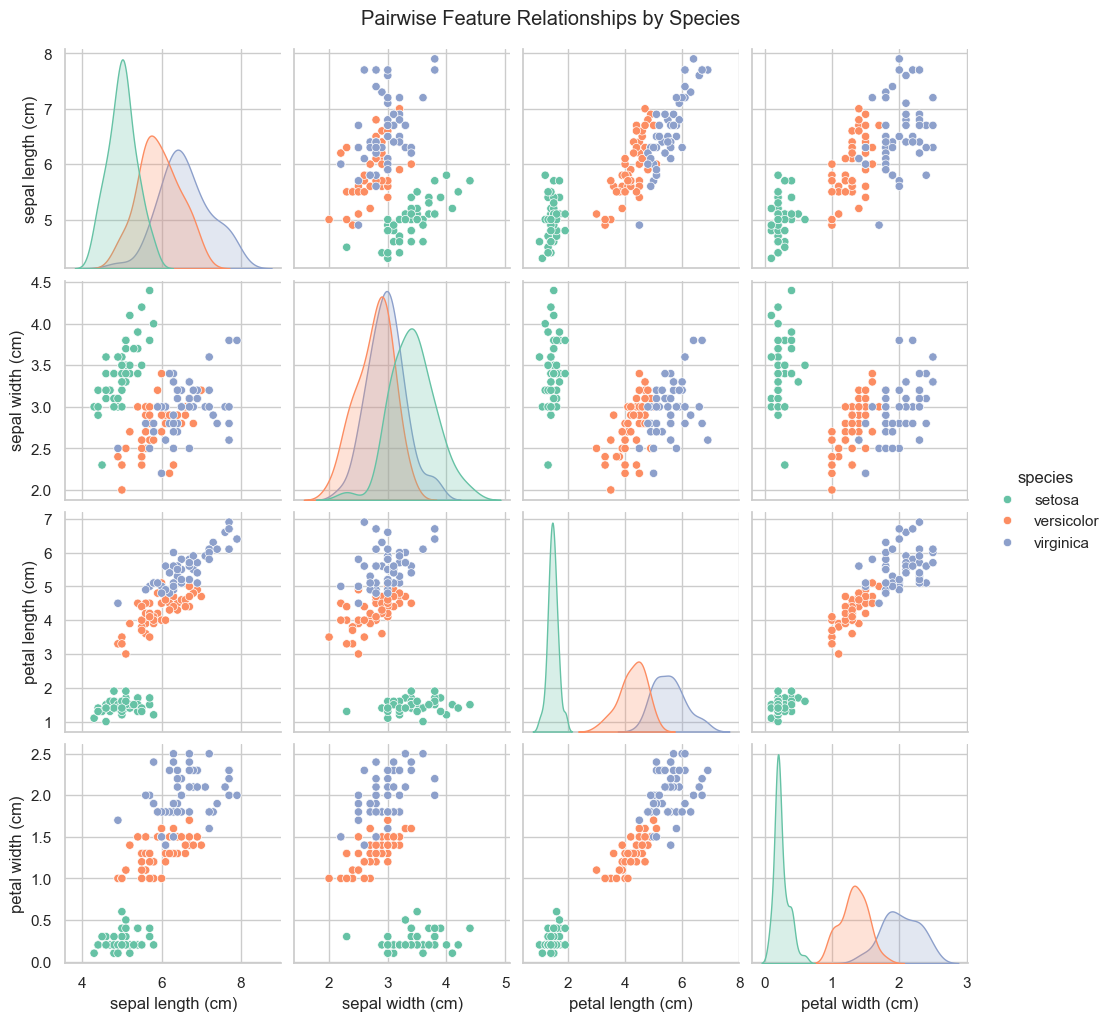

In [6]:
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()

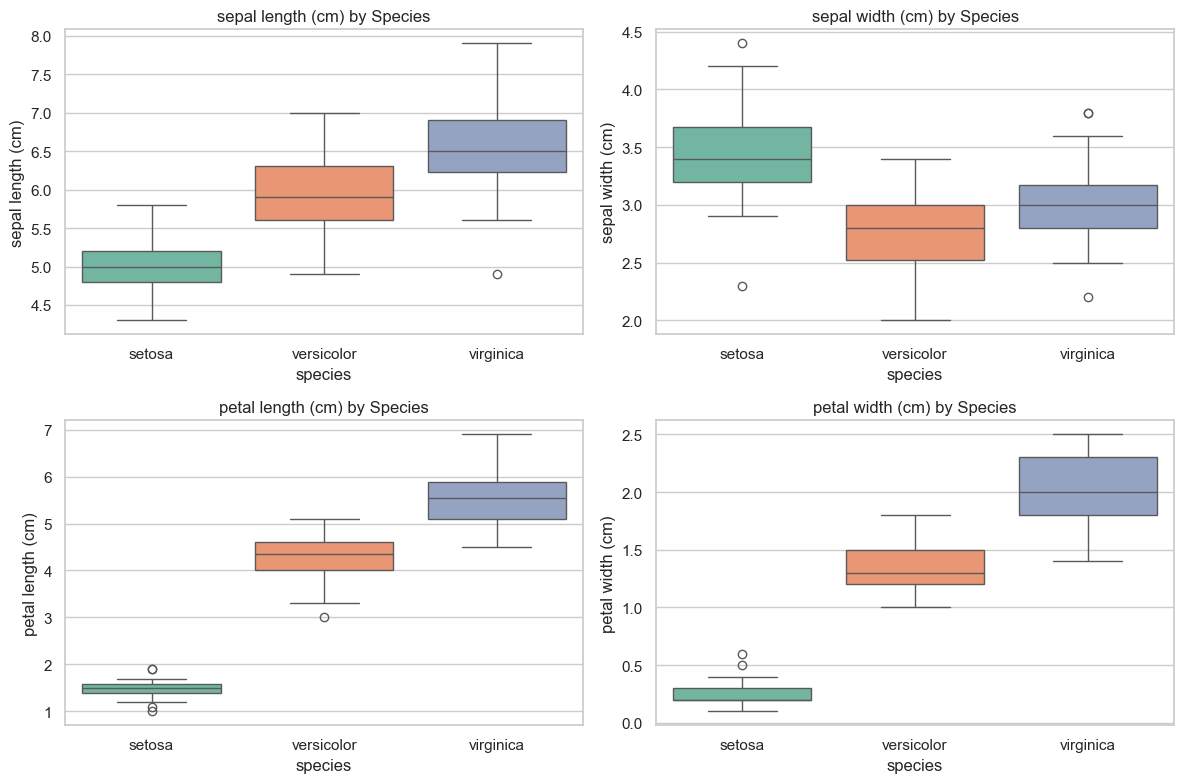

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, hue='species',
                palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()

## 4. Feature Selection Discussion

When I Looked at the pairplot, I noticed that petal length and petal width separate the three species the best. Setosa is almost completely on its own, and even Versicolor and Virginica only overlap a little bit on these two features.

Sepal length and sepal width aren't as useful on their own — Versicolor and Virginica overlap a lot more there, so it's harder to tell them apart using just sepal measurements.

Because of this, I think petal length and petal width will matter the most when it comes to predicting the species. That said, I still used all four features to train my models, since the dataset is small anyway and adding sepal measurements doesn't really hurt.

## 5. Train/Test Split

In [8]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


## 6. Train Classifiers
We train three classifiers here (more than the required 2) to give a broader comparison: Logistic Regression, K-Nearest Neighbours, and Decision Tree.

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
K-Nearest Neighbours trained.
Decision Tree trained.


## 7. Evaluation
For each model: accuracy score, confusion matrix, and classification report (precision, recall, F1).

===== Logistic Regression =====
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



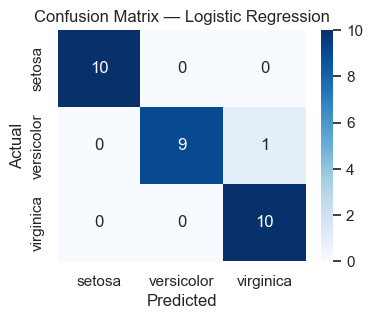



===== K-Nearest Neighbours =====
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



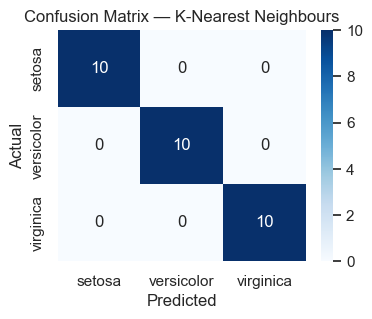



===== Decision Tree =====
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



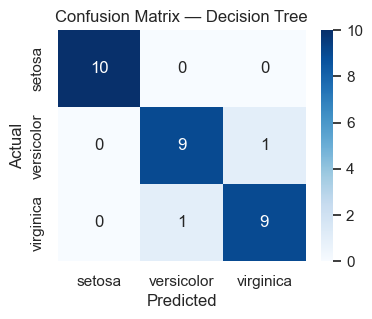

In [10]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"===== {name} =====")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("\n")

In [11]:
# Side-by-side accuracy comparison
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
1,K-Nearest Neighbours,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333


## 8. Best-Performing Model & Conclusion

Out of the three models I trained, KNN performed the best with 100% accuracy on the test data. Logistic Regression was close behind at 96.7%, and Decision Tree got 93.3%.

When I checked the classification reports, KNN got every single flower right — no mistakes at all for any of the three species. Logistic Regression got one Versicolor flower wrong (it predicted Virginica instead), and Decision Tree made two similar mistakes in that same area. Setosa was easy for all three models to identify correctly, but Versicolor and Virginica are harder to tell apart since their measurements overlap a bit. That's basically where KNN did better than the other two — it handled that tricky overlap without making a single error.